# Finding emission-line candidates in the Vela X-1 RGS spectrum

This worked example uses **RGS1, first order, observation 0841890201**, with a search interval of **0.62–0.92 keV**. It illustrates loading a spectrum, exploring rebinning, inspecting an empirical baseline, detecting candidates, evaluating them with synthetic spectra, and fitting and identifying selected features.

## Before you start

- Install this checkout of BLiSS and its dependencies in the notebook's Python environment. From the repository root, `python -m pip install -e ".[notebooks]"` installs the editable package and notebook support.
- Run the notebook from the repository's `notebook/` directory, or update `rgs_path` below.
- Supply the source spectrum, background spectrum and response listed in Section 2. The data must be available locally; the notebook does not download them.

The intended workflow is: **input data → rebinning → baseline → candidate search → simulation-based evaluation → selection and global fit → tentative atomic identification**.

## 1. Imports and search configuration

Import the public BLiSS functions and the numerical, plotting, path and timing utilities used below.

In [1]:
# Import the public BLiSS API and the utilities used throughout this notebook.
from bliss import *
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

from bliss.line_search.blind_line_search import (
    BlindLineSearchConfig,)

### 1.1 Define the configuration

`BlindLineSearchConfig` holds the search settings. Commented-out arguments use the library defaults; they do not inherit values from earlier cells. Here the active overrides include a 0.1 keV energy margin, a maximum Gaussian sigma of 0.005 keV (5 eV), and Poisson simulations.

**Execution dependency:** `en1` and `en2` are first assigned later in the saved notebook. For a fresh session, define `en1, en2 = 0.62, 0.92` before this cell.

Creating `pipeline` does not execute a search. The later calls to `find_candidate_lines` construct their own pipeline. Only the evaluated search explicitly receives this `config`; keyword arguments in that call can override it.

In [2]:
en1 = 0.5
en2 = 2.2
# Define en1 and en2 before this cell in a fresh kernel.
# Commented arguments use defaults; this pipeline object is not run below.
config = BlindLineSearchConfig(
    # Search interval (keV)
    en1=en1,                           # Default: 0.2
    en2=en2,                           # Default: 10.0
    energy_pad=0.1,                    # Extra margin on each side, in keV

    # Rebinning
    #rebin_method=rebin_method,         # Default: "none"
    #rebin_scale=rebin_scale,           # Default: None
    #rebin_min_bins=1,                  # Minimum input bins per group for "snr"

    # Baseline
    #baseline_window=window_fn,         # Default: 0.4 keV
    #max_range_fraction=0.2,            # Maximum window / input energy range
    #min_points=3,                     # Minimum points for the local median

    # Line fitting
    max_sigma_line=0.005,                # Maximum Gaussian sigma, in keV
    #final_fit_maxfev=100000,           # Maximum global-fit function evaluations

    # Simulations
    #num_synthetic_simulations=100,     # Default: 10; 0 disables simulations
    #synthetic_seed=None,              # Use an integer for reproducibility
    noise_model="poisson",             # "gaussian" for validation/comparison

    # Evaluation and flags
    #min_area_snr=None,                # No preliminary area-S/N cut for the GMM
    #response_feature_threshold=5.0,   # Threshold for flagging ARF structure
)

pipeline = BlindLineSearchPipeline(config=config)

## 2. Locate the RGS files and load the spectrum

| File | Role |
|---|---|
| `vela_RGS1_order1_grp.fits` | Source spectrum with grouping flags previously written by SAS |
| `P0841890201R1S004RSPMAT1001.FIT` | Corresponding RGS response |
| `P0841890201R1S004BGSPEC1001.FIT` | Background spectrum |

This call subtracts the supplied background and propagates its uncertainty. It uses the default `rebin_method="none"`.

**Loader behavior in this checkout:** the FITS `GROUPING` and `QUALITY` columns are not applied by `prepare_spectrum`. The following examples apply BLiSS rebinning explicitly.

In [3]:
# Load a background-subtracted spectrum; SAS GROUPING flags are not applied by this loader.
rgs_path = Path("./0841890201/odf/")  # Directory containing the FITS files

pha = rgs_path / "vela_RGS1_order1_grp.fits"
rmf = rgs_path / "P0841890201R1S004RSPMAT1001.FIT"
bkg = rgs_path / "P0841890201R1S004BGSPEC1001.FIT"

spectrum = prepare_spectrum(
    pha_path=pha,
    rmf_path=rmf,
    background_path=bkg,
)

## 3. Inspect the native spectrum and compare rebinning choices

The plotting helper restricts the plotted arrays to the requested energy interval. The printed median bin width is computed over the entire loaded spectrum, not just the displayed interval.

### 3.1 Native channels

`rebin_method="none"` preserves the retained input channels. **Unlike Section 2, this call does not pass a background file**, so `native` contains the source-region spectrum without background subtraction. It is a separate object from `spectrum`.

2303 channels, median width 0.26 eV, exposure 113470 s


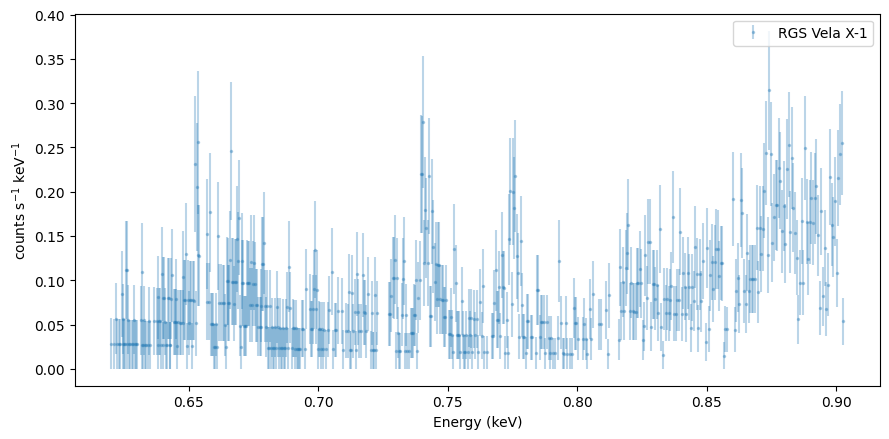

In [4]:
# This native-channel example omits the background file.
# The plotting mask changes the displayed range, not the stored spectrum.
def plot_spectrum(spectra, labels, xlim, title=None):
    plt.figure(figsize=(9, 4.5))
    for i, (s, lab) in enumerate(zip(spectra, labels)):
        m = (s.energy >= xlim[0]) & (s.energy <= xlim[1])
        plt.errorbar(s.energy[m], s.values[m], yerr=s.uncertainties[m],
                     fmt=".", ms=3 if i == 0 else 4, alpha=0.3 if i == 0 else 0.9, label=lab)
    plt.xlabel("Energy (keV)")
    plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
    if title:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


native = prepare_spectrum(pha, rmf, rebin_method="none")
print(f"{len(native.energy)} channels, median width {1e3*np.median(native.bin_width):.2f} eV, "
      f"exposure {native.native.exposure:.0f} s")

plot_spectrum([native], ["RGS Vela X-1"], xlim=(0.62, 0.92))


### 3.2 Group by signal-to-noise ratio

`rebin_method="snr", rebin_scale=3.0` accumulates adjacent input bins until their combined signal-to-noise ratio reaches 3. This can produce wider bins in weak parts of the spectrum; a trailing group can fall below the requested threshold.


981 bins, median width 1.38 eV, exposure 113470 s


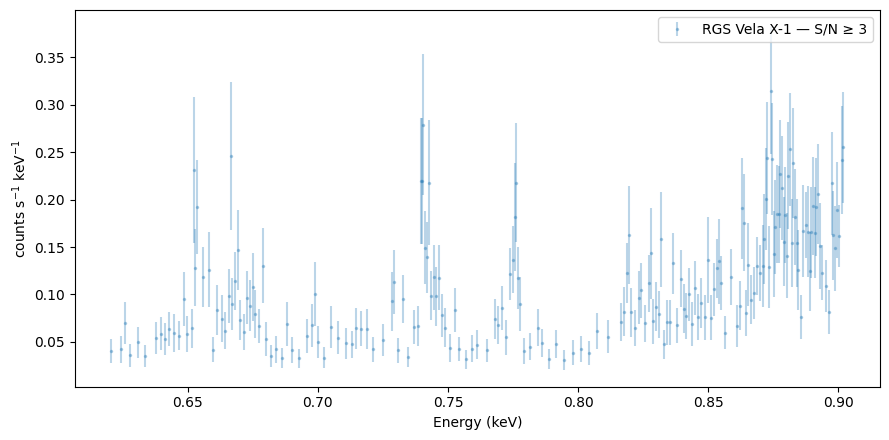

In [5]:
# S/N-based grouping of the source-region spectrum (no background passed here).
spectrum_snr = prepare_spectrum(
    pha,
    rmf,
    rebin_method="snr",
    rebin_scale=3.0,
)

print(
    f"{len(spectrum_snr.energy)} bins, "
    f"median width {1e3 * np.median(spectrum_snr.bin_width):.2f} eV, "
    f"exposure {spectrum_snr.native.exposure:.0f} s"
)

plot_spectrum(
    [spectrum_snr],
    ["RGS Vela X-1 — S/N ≥ 3"],
    xlim=(0.62, 0.92),
)

### 3.3 Group a fixed number of channels

`rebin_method="bins", rebin_scale=3` combines groups of three retained input bins, sums their values, and propagates errors in quadrature. The implementation merges any incomplete trailing group into the preceding group. This is a channel-count criterion, not a constant energy width.

Here `background_path=bkg` is supplied, so `spectrum_bins` is background-subtracted. To compare grouping methods alone, all examples would need the same treatment of the background.

891 bins, median width 0.71 eV, exposure 113470 s


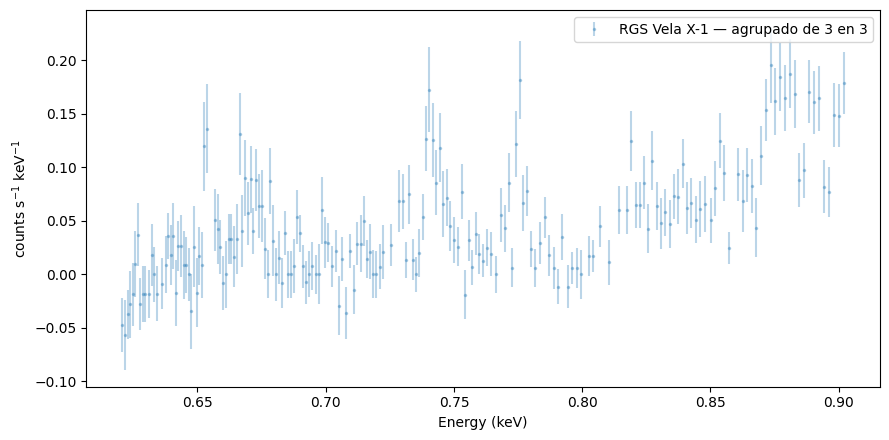

In [6]:
# Combine three input bins per group after background subtraction.
spectrum_bins = prepare_spectrum(
    pha_path=pha,
    rmf_path=rmf,
    background_path=bkg,
    rebin_method="bins",
    rebin_scale=3,
)

print(
    f"{len(spectrum_bins.energy)} bins, "
    f"median width {1e3 * np.median(spectrum_bins.bin_width):.2f} eV, "
    f"exposure {spectrum_bins.native.exposure:.0f} s"
)

plot_spectrum(
    [spectrum_bins],
    ["RGS Vela X-1 — agrupado de 3 en 3"],
    xlim=(0.62, 0.92),
)

### 3.4 Repeated fixed-channel grouping cell

The following cell currently repeats Section 3.3 and overwrites `spectrum_bins` with the same settings. Its earlier “Resolution” heading did not describe the code.

For a separate fixed-energy-width experiment, BLiSS accepts `rebin_method="resolution", rebin_scale=0.002` (2 eV). That method uses fixed energy intervals; it does not automatically follow the RGS instrumental resolution. The code below has been retained as written.

891 bins, median width 0.71 eV, exposure 113470 s


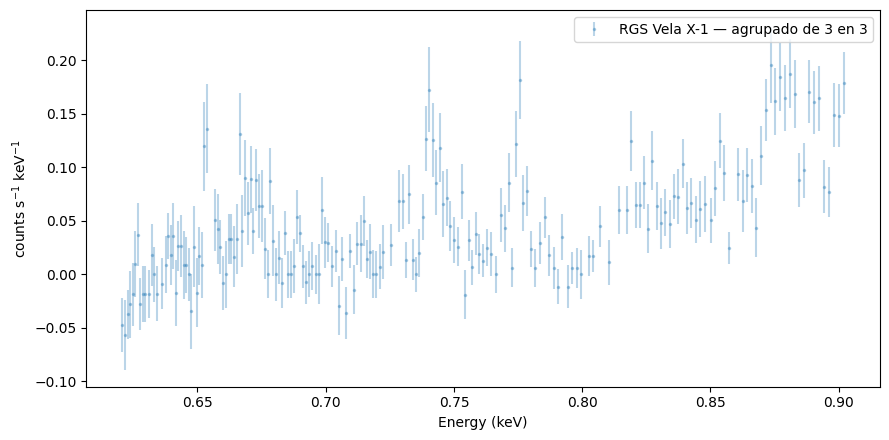

In [7]:
# This repeats the preceding fixed-channel example; it is not resolution-based grouping.
spectrum_bins = prepare_spectrum(
    pha_path=pha,
    rmf_path=rmf,
    background_path=bkg,
    rebin_method="bins",
    rebin_scale=3,
)

print(
    f"{len(spectrum_bins.energy)} bins, "
    f"median width {1e3 * np.median(spectrum_bins.bin_width):.2f} eV, "
    f"exposure {spectrum_bins.native.exposure:.0f} s"
)

plot_spectrum(
    [spectrum_bins],
    ["RGS Vela X-1 — agrupado de 3 en 3"],
    xlim=(0.62, 0.92),
)

## 4. Inspect the empirical baseline

BLiSS estimates a baseline using a running median in energy. This is an empirical description of the observed spectral shape, not a physical continuum model. A window that is too narrow can absorb line structure; a very broad window can miss changes in the underlying spectrum.

The baseline is calculated over the full `spectrum_bins` grid. Plot limits only change the displayed region. The effective window is capped at `max_range_fraction` (default 0.2) times the full input energy range.

### 4.1 Default requested window: 0.4 keV

**Execution note:** this cell stores diagnostics in `info_bins`, but the print statement reads `info`. It should read `info_bins['window_width']` to report the baseline calculated here. The fixed Y limits are a visual zoom and can hide points or error bars.

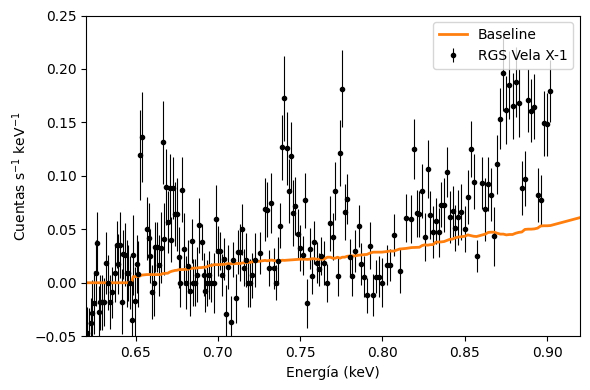

In [8]:
# Compute the baseline on the full spectrum, then display an energy zoom.
# TODO: the diagnostic print should use info_bins, not info.
baseline_window = 0.4 #Default

baseline_bins, info_bins = base_calculator(
    spectrum_bins.energy,
    spectrum_bins.values,
    baseline_window=baseline_window,
    return_info=True)


fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    spectrum_bins.energy,
    spectrum_bins.values,
    yerr = spectrum_bins.uncertainties,
    fmt=".",
    color="black",
    linewidth=0.8,
   
    label="RGS Vela X-1", 
)

ax.plot(
    spectrum_bins.energy,
    baseline_bins,
    color="tab:orange",
    linewidth=2,
    label="Baseline",
)

ax.set(
    xlim=(0.62, 0.92),
    xlabel="Energía (keV)",
    ylabel=r"Cuentas s$^{-1}$ keV$^{-1}$",
)

plt.ylim(-0.05,0.25)
ax.legend()
fig.tight_layout()
plt.show()

### 4.2 Compare a smaller requested window: 0.05 keV

This cell recomputes `baseline_bins` with a 50 eV window. It overwrites the previous baseline but does not update `config.baseline_window`.

**Execution note:** the print statement still reads `info` rather than `info_bins`, and the orange curve uses `baseline` rather than the newly computed `baseline_bins`. These references must be corrected before treating the plot as a comparison of the two windows.

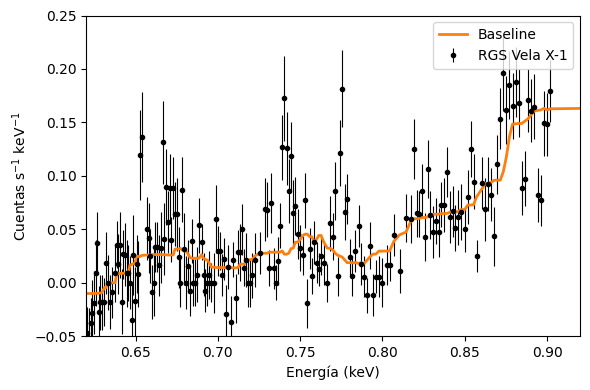

In [9]:
# Compare a smaller baseline window on the same spectrum.
# TODO: use info_bins in the print and baseline_bins in the plotted curve.
baseline_window = 0.05


baseline_bins, info_bins = base_calculator(
    spectrum_bins.energy,
    spectrum_bins.values,
    baseline_window=baseline_window,
    return_info=True,
)


fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    spectrum_bins.energy,
    spectrum_bins.values,
    yerr = spectrum_bins.uncertainties,
        fmt=".",
    color="black",
    linewidth=0.8,
    label="RGS Vela X-1", 
)

ax.plot(
    spectrum_bins.energy,
    baseline_bins,
    color="tab:orange",
    linewidth=2,
    label="Baseline",
)

ax.set(
    xlim=(0.62, 0.92),
    xlabel="Energía (keV)",
    ylabel=r"Cuentas s$^{-1}$ keV$^{-1}$",
)

plt.ylim(-0.05,0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Run a quick candidate search without simulations

Setting `num_synthetic_simulations=0` detects and locally fits candidates without assigning simulation-based significance. This is useful for an initial inspection; the resulting candidates are not confirmed detections.

This call uses **two-bin grouping**, omits the background, and does **not** receive `config`. It therefore uses the default baseline and line-width settings rather than the custom configuration above. The timer measures the entire function call, including loading and preparation.

In [10]:
# Quick search: no simulations, no background, and no custom config.
# The two-bin grouping differs from the evaluated search below.
en1, en2 = 0.62, 0.92

inicio = perf_counter()

candidate_lines_not_evaluated = find_candidate_lines(
    pha=pha,
    rmf=rmf,
    rebin_method="bins",
    rebin_scale=4,
    en1=en1,
    en2=en2,
    num_synthetic_simulations=0,
    synthetic_seed=1,
)

tiempo = perf_counter() - inicio

print(f"Tiempo total: {tiempo:.2f} s ({tiempo / 60:.2f} min)")

Tiempo total: 5.28 s (0.09 min)


### 5.1 Overlay candidate energies

The vertical markers show the centers returned by the quick search. They indicate positions only, not line widths or significance.

The display uses `spectrum_bins` (three-bin grouping with background subtraction), while the quick search used two-bin grouping without background subtraction. This overlay is therefore a qualitative location check, not a plot of the exact data used for detection. The Y limits are manually fixed.

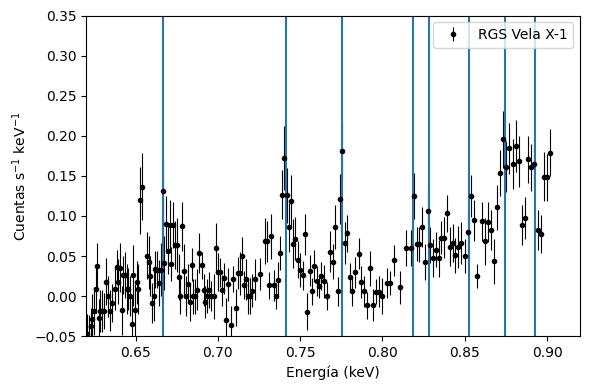

In [11]:
# Mark quick-search centers on a separately prepared three-bin spectrum.
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    spectrum_bins.energy,
    spectrum_bins.values,
    yerr = spectrum_bins.uncertainties,
        fmt=".",
    color="black",
    linewidth=0.8,
    label="RGS Vela X-1", 
)

ax.set(
    xlim=(0.62, 0.92),
    xlabel="Energía (keV)",
    ylabel=r"Cuentas s$^{-1}$ keV$^{-1}$",
)

for i in range(len(candidate_lines_not_evaluated )):
    plt.vlines(x=candidate_lines_not_evaluated .center[i], ymin=-1, ymax=2)



plt.ylim(-0.05,0.35)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Evaluate candidates with 100 synthetic spectra

The evaluated search uses three-bin grouping and a fixed random seed. Poisson null spectra provide a reference for the BLiSS score and the five `p_global_*` statistics.

With 100 simulations, the smallest attainable Monte Carlo p-value is **1 / (100 + 1) ≈ 0.0099**. This is the resolution of the estimator, not a guarantee that probabilities near that value are measured precisely. Each global p-value compares one statistic with the maximum found across the search interval in each null realization; it does not correct for selecting among several statistics after inspecting the results.

This call receives `config`, but its explicit grouping, interval, simulation count and seed override the corresponding fields. In the current wrapper, omitted `energy_pad` defaults to **0.0**, overriding the 0.1 value in `config`. The baseline remains **0.4 keV** and the maximum sigma is **0.005 keV**, provided the configuration above has not been changed. No background file is passed.

The score plot summarizes the evaluated candidates. A BLiSS score is not interchangeable with a global p-value.

Tiempo total: 18.51 s (0.31 min)


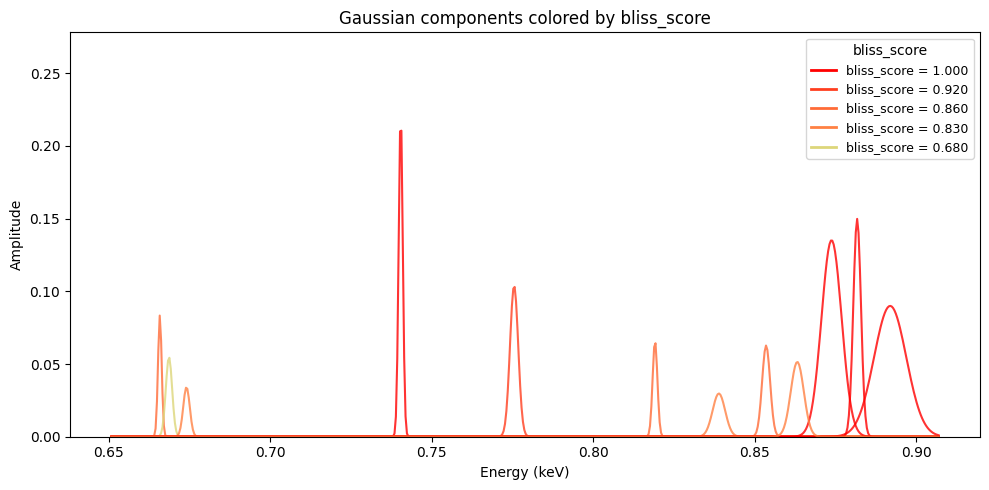

In [12]:
# Evaluated search: these keyword arguments override the supplied config.
# No background is passed; the wrapper also defaults energy_pad to zero.
en1, en2 = 0.62, 0.92

inicio = perf_counter()

candidate_lines_evaluated = find_candidate_lines(
    pha=pha,
    rmf=rmf,
    rebin_method="bins",
    rebin_scale=3,
    en1=en1,
    en2=en2,
    num_synthetic_simulations=100,
    synthetic_seed=1,
    config=config
)

tiempo = perf_counter() - inicio

print(f"Tiempo total: {tiempo:.2f} s ({tiempo / 60:.2f} min)")
plot_bliss_score(candidate_lines_evaluated)

### 6.1 Inspect the evaluated candidate catalogue

Review fitted centers and widths, their uncertainties, areas, equivalent widths, BLiSS scores and global p-values. Missing scores or p-values indicate unavailable evaluation, not a numerical significance of zero.

In [13]:
# Inspect local-fit measurements and simulation-based evaluation before filtering.
candidate_lines_evaluated

,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,ew,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,0.665883,0.000787,0.000568,0.000559,0.083514,0.046067,0.000119,0.000090,1.786975,0.378785,3.051341,1.328422,0.86,False,0.693069,0.792079,0.297030,0.623762,0.009901
1,0.668708,0.000853,0.000980,0.000945,0.054763,0.031856,0.000135,0.000101,2.007482,0.260308,2.000871,1.333322,0.68,False,0.613861,0.792079,0.693069,0.584158,0.405941
2,0.674129,0.000866,0.001004,0.000857,0.034122,0.026772,0.000086,0.000064,1.269307,0.174558,1.378677,1.341743,0.83,False,0.900990,0.782178,0.910891,0.891089,0.811881
3,0.740442,0.000251,0.000635,0.000354,0.222489,0.131156,0.000354,0.000070,5.306076,0.563989,8.670335,5.062804,1.00,False,0.069307,0.009901,0.019802,0.059406,0.009901
4,0.775537,0.000387,0.001271,0.000351,0.103920,0.029107,0.000331,0.000086,4.958637,0.388400,4.392523,3.863124,0.92,False,0.069307,0.009901,0.069307,0.069307,0.009901
5,0.819149,0.000816,0.000742,0.000382,0.065816,0.027448,0.000122,0.000073,1.749196,0.319564,3.157821,1.677738,0.86,False,0.653465,0.534653,0.257426,0.653465,0.069307
6,0.838916,0.001392,0.001941,0.001371,0.029739,0.019577,0.000145,0.000090,1.965965,0.168618,1.415535,1.614462,0.83,False,0.574257,0.564356,0.900990,0.603960,0.851485
7,0.853544,0.000626,0.001238,0.000489,0.062743,0.025346,0.000195,0.000079,2.600492,0.268961,3.006644,2.455276,0.86,False,0.267327,0.099010,0.306931,0.346535,0.316832
8,0.873799,0.003455,0.003109,0.002311,0.135199,0.044324,0.001054,0.001031,14.376444,0.515334,5.175002,1.021681,1.00,False,0.009901,0.910891,0.049505,0.009901,0.009901
9,0.891942,0.001070,0.005000,0.001333,0.089969,0.015968,0.001128,0.000234,15.215027,0.423479,3.443740,4.819830,1.00,False,0.009901,0.009901,0.158416,0.009901,0.009901


## 7. Select candidates and perform a global fit

The example keeps candidates with `bliss_score > 0.5` and jointly fits their line profiles. This is an illustrative score threshold; it is not equivalent to `p_global_area < 0.05` or a 50% probability that a line is real.

**Settings to reconcile before interpreting the fit:** the evaluated search uses three-bin grouping and the configured 0.4 keV baseline, whereas this cell uses `spectrum_snr` and a 0.025 keV baseline. It also omits `max_sigma_line`, so the global fit defaults to 0.1 keV rather than the search's 0.005 keV. The search and global fit should use consistent spectrum preparation, baseline and width bounds.

`energy_min` and `energy_max` control the diagnostic plot only; they do not restrict the fitted data. The retained simulation scores and p-values describe the earlier local search and are not recalculated by this global fit.

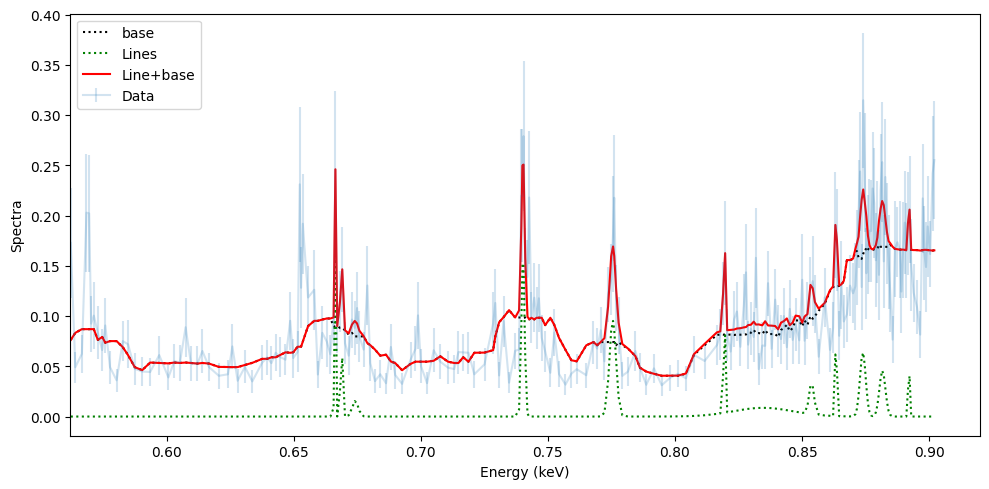

In [14]:
# This score threshold is not a p-value threshold.
# TODO: align spectrum preparation, baseline and max_sigma_line with the evaluated search.
candidate_lines_evaluated_filtered = candidate_lines_evaluated[candidate_lines_evaluated.bliss_score>0.0025]

lines_res_global = fit_global(
    candidate_lines_evaluated_filtered ,
    spectrum_snr,
    baseline_window=0.025,
    energy_min=0.562,
    energy_max=0.92)


## 8. Assign tentative atomic identifications

`add_most_probable_ion` compares each fitted center with the bundled atomic line table, using a matching tolerance corresponding to 600 km s⁻¹. Among compatible transitions, the current implementation selects the one ranked highest by the table's `scaled_prob` value. Unmatched lines receive `ion="--"` and a missing velocity.

These are candidate identifications, not unique physical assignments. The returned `doppler_kms` uses **c × (E_observed − E_rest) / E_rest**: positive values mean higher observed energy (a blueshift). The matching tolerance is not a measured velocity uncertainty.

In [15]:
# Tentative table-based identifications within a 600 km/s matching tolerance.
global_lines = add_most_probable_ion(lines_res_global, v_doppler_kms=600)
global_lines

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,area,earea,...,relative_power,snr_peak,snr_area,bliss_score,response_feature,p_global_area,p_global_snr_area,p_global_snr_peak,p_global_ew,p_global_relative_power
0,o_vii,274.567745,0.666225,0.015728,0.000211,0.009196,0.223805,21.023095,0.000118,0.005942,...,0.378785,8.177079,0.019889,0.86,False,0.693069,0.792079,0.297030,0.623762,0.009901
1,fe_xviii,584.356789,0.668744,0.034532,0.000325,0.059375,0.106204,35.675059,0.000087,0.013253,...,0.260308,3.880328,0.006528,0.68,False,0.613861,0.792079,0.693069,0.584158,0.405941
2,ca_xix,-448.733523,0.674211,0.002103,0.001145,0.001943,0.015634,0.023999,0.000045,0.000069,...,0.174558,0.631678,0.645679,0.83,False,0.900990,0.782178,0.910891,0.891089,0.811881
3,o_vii,593.392129,0.740211,0.000214,0.000619,0.000189,0.161857,0.053871,0.000251,0.000073,...,0.563989,6.307528,3.416931,1.00,False,0.069307,0.009901,0.019802,0.059406,0.009901
4,o_viii,348.042709,0.775510,0.000407,0.001290,0.000387,0.095527,0.030428,0.000309,0.000085,...,0.388400,4.037744,3.642994,0.92,False,0.069307,0.009901,0.069307,0.069307,0.009901
5,ne_v,-407.548976,0.819374,0.101887,0.000236,0.241047,0.240268,714.544374,0.000142,0.277646,...,0.319564,11.527904,0.000512,0.86,False,0.653465,0.534653,0.257426,0.653465,0.069307
6,ne_vi,-240.739789,0.834690,0.013177,0.011763,0.014483,0.008674,0.007199,0.000256,0.000263,...,0.168618,0.412846,0.970778,0.83,False,0.574257,0.564356,0.900990,0.603960,0.851485
7,ne_iii,-447.296561,0.853729,0.001080,0.000959,0.001075,0.031516,0.032085,0.000076,0.000083,...,0.268961,1.510221,0.913249,0.86,False,0.267327,0.099010,0.306931,0.346535,0.316832
8,ne_v,414.674627,0.873905,0.000719,0.001129,0.000710,0.063923,0.036807,0.000181,0.000099,...,0.515334,2.446764,1.834047,1.00,False,0.009901,0.910891,0.049505,0.009901,0.009901
9,ne_vii,-398.511915,0.892006,0.008975,0.000227,0.030496,0.089682,23.801627,0.000051,0.006689,...,0.423479,3.432769,0.007630,1.00,False,0.009901,0.009901,0.158416,0.009901,0.009901
